# 1. Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

C:\Users\Utilizador\anaconda3\envs\heartfailure\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Data Loading

In [2]:
try:
    path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")
    file = os.path.join(path, 'heart_failure_clinical_records_dataset.csv')

    df = pd.read_csv(file)
    print("Shape: ", df.shape)
    print(path)
    display(df.head(20))
    
except Exception as e:
    print(f"Error: {e}")

Shape:  (299, 13)
C:\Users\Utilizador\.cache\kagglehub\datasets\andrewmvd\heart-failure-clinical-data\versions\1


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


# 3. Pre-processing

In [3]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '_')
df = df.drop_duplicates()

In [4]:
cols = df.select_dtypes(include='string').columns
for col in cols:
    df[col] = df[col].str.strip().str.lower()


# 4. Data Overview

In [5]:
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])
print("Duplicate rows: ", df.duplicated().sum())
print("Total missing values: ", df.isna().sum().sum())
df.head(5)

Rows:  299
Columns:  13
Duplicate rows:  0
Total missing values:  0


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
display(df.dtypes)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
death_event                   int64
dtype: object

# 5. Machine Learning

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('death_event', axis=1)
y = df['death_event']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape[0]}")
print(f"y_test shape:  {y_test.shape[0]}")

X_train shape: (239, 12)
X_test shape:  (60, 12)
y_train shape: 239
y_test shape:  60


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("x_trained_scaled mean (~0):", X_train_scaled.mean().round(2))
print("x_test_scaled std deviation (~1):", X_test_scaled.std().round(2))

x_trained_scaled mean (~0): 0.0
x_test_scaled std deviation (~1): 0.96


# 5.1. Logistic Regression

=== Logistic Regression ===
MCC: 0.556
ROC-AUC: 0.859
Accuracy: 0.817
              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



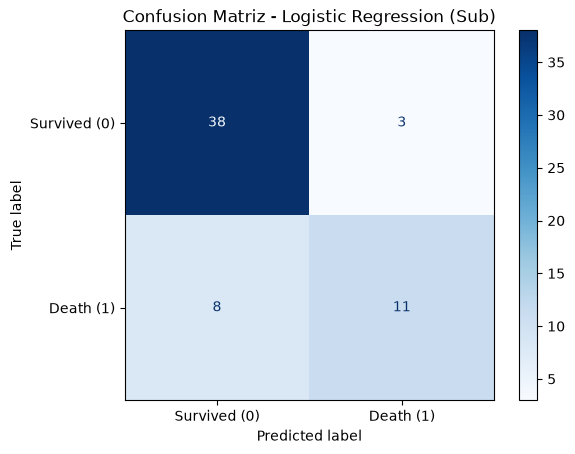

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
acc = log_reg.score(X_test_scaled, y_test)

print("=== Logistic Regression ===")
print(f"MCC: {matthews_corrcoef(y_test, y_pred_log):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log):.3f}")
print(f"Accuracy: {acc:.3f}")
print(classification_report(y_test, y_pred_log))

cm_lr = confusion_matrix(y_test, y_pred_log)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Survived (0)', 'Death (1)'])

disp_lr.plot(cmap='Blues')
plt.title('Confusion Matriz - Logistic Regression (Sub)')
plt.grid(False)
plt.show()

In [11]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0]),
    'Abs_Coeficiente': np.abs(log_reg.coef_[0])
}).sort_values(by='Abs_Coeficiente', ascending=False)

print(feature_importance)

                     Feature  Coeficiente  Odds_Ratio  Abs_Coeficiente
11                      time    -1.577011    0.206592         1.577011
4          ejection_fraction    -0.909601    0.402685         0.909601
7           serum_creatinine     0.787676    2.198281         0.787676
0                        age     0.416343    1.516406         0.416343
2   creatinine_phosphokinase     0.275913    1.317733         0.275913
3                   diabetes     0.242201    1.274051         0.242201
9                        sex    -0.200936    0.817965         0.200936
6                  platelets    -0.139808    0.869525         0.139808
8               serum_sodium    -0.137449    0.871579         0.137449
10                   smoking     0.111317    1.117750         0.111317
1                    anaemia     0.090645    1.094880         0.090645
5        high_blood_pressure     0.049263    1.050497         0.049263


In [12]:
import statsmodels.api as sm

X_train_scaled_df = pd.DataFrame(
    X_train_scaled, columns=X_train.columns, index=y_train.index
)
X_with_const = sm.add_constant(X_train_scaled_df) 
logit_model = sm.Logit(y_train, X_with_const).fit()

print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.355674
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            death_event   No. Observations:                  239
Model:                          Logit   Df Residuals:                      226
Method:                           MLE   Df Model:                           12
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.4341
Time:                        12:21:30   Log-Likelihood:                -85.006
converged:                       True   LL-Null:                       -150.21
Covariance Type:            nonrobust   LLR p-value:                 5.106e-22
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -1.3755      0.234     -5.866      0.000      -1.835

=== Logistic Regression (4 Variables) ===
MCC: 0.599
ROC-AUC: 0.864
Accuracy: 0.833
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60



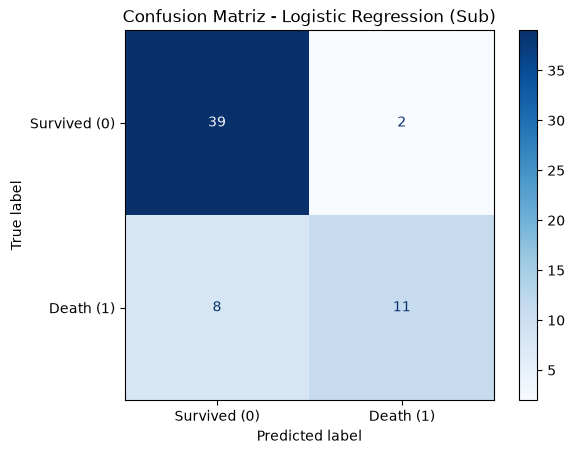

In [14]:
X_train_sub = X_train[['age', 'ejection_fraction', 'serum_creatinine', 'time']]
X_test_sub = X_test[['age', 'ejection_fraction', 'serum_creatinine', 'time']]

scaler_sub = StandardScaler()
X_train_scaled_sub = scaler_sub.fit_transform(X_train_sub)
X_test_scaled_sub = scaler_sub.transform(X_test_sub)

log_reg_sub = LogisticRegression(random_state=42)
log_reg_sub.fit(X_train_scaled_sub, y_train)
acc_sub = log_reg_sub.score(X_test_scaled_sub, y_test)

y_pred_log_sub = log_reg_sub.predict(X_test_scaled_sub)
y_prob_log_sub = log_reg_sub.predict_proba(X_test_scaled_sub)[:, 1]

print("=== Logistic Regression (4 Variables) ===")
print(f"MCC: {matthews_corrcoef(y_test, y_pred_log_sub):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_log_sub):.3f}")
print(f"Accuracy: {acc_sub:.3f}")
print(classification_report(y_test, y_pred_log_sub))

cm_lr_sub = confusion_matrix(y_test, y_pred_log_sub)
disp_lr_sub = ConfusionMatrixDisplay(confusion_matrix=cm_lr_sub, display_labels=['Survived (0)', 'Death (1)'])

disp_lr_sub.plot(cmap='Blues')
plt.title('Confusion Matriz - Logistic Regression (Sub)')
plt.grid(False)
plt.show()

# 5.2 Random Forest

=== Random Forest (All Variables) ===
MCC: 0.599
ROC-AUC: 0.909
Accuracy: 0.833
              precision    recall  f1-score   support

           0       0.83      0.95      0.89        41
           1       0.85      0.58      0.69        19

    accuracy                           0.83        60
   macro avg       0.84      0.77      0.79        60
weighted avg       0.83      0.83      0.82        60



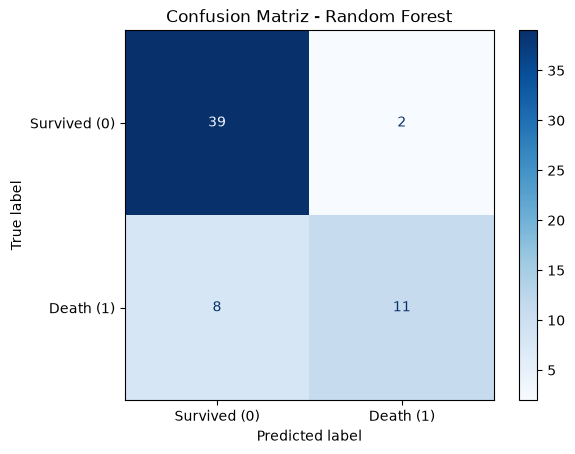

In [15]:
from sklearn.ensemble import RandomForestClassifier
 
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
acc_rf = rf.score(X_test, y_test)

print("=== Random Forest (All Variables) ===")
print(f"MCC: {matthews_corrcoef(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(f"Accuracy: {acc_rf:.3f}")
print(classification_report(y_test, y_pred))

cm_rf = confusion_matrix(y_test, y_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Survived (0)', 'Death (1)'])

disp_rf.plot(cmap='Blues')
plt.title('Confusion Matriz - Random Forest')
plt.grid(False)
plt.show()

In [ ]:
X_train_sub = X_train[['age', 'ejection_fraction', 'serum_creatinine', 'time']]
X_test_sub = X_test[['age', 'ejection_fraction', 'serum_creatinine', 'time']]

rf.fit(X_train_sub, y_train)
y_pred_sub = rf.predict(X_test_sub)
y_prob_sub = rf.predict_proba(X_test_sub)[:, 1]
acc_rf_sub = rf.score(X_test_sub, y_test)

print("=== Random Forest (4 Variables) ===")
print(f"MCC: {matthews_corrcoef(y_test, y_pred_sub):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_sub):.3f}")
print(f"Accuracy: {acc_rf_sub:.3f}")
print(classification_report(y_test, y_pred_sub))

cm_rf_sub = confusion_matrix(y_test, y_pred_sub)
disp_rf_sub = ConfusionMatrixDisplay(confusion_matrix=cm_rf_sub, display_labels=['Survived (0)', 'Death (1)'])

disp_rf_sub.plot(cmap='Blues')
plt.title('Confusion Matriz - Random Forest (Reduced Variables)')
plt.grid(False)
plt.show()

In [ ]:
data = {
    "Algoritmo": [
        "Regressão Logística",
        "Regressão Logística",
        "Random Forest",
        "🏆 Random Forest"
    ],
    "Conjunto de Variáveis": [
        "Todas (12)",
        "Reduzidas (4)",
        "Todas (12)",
        "Reduzidas (4)"
    ],
    "Accuracy": [0.817, 0.817, 0.833, 0.850],
    "MCC": [0.556, 0.599, 0.599, 0.641],
    "ROC-AUC": [0.859, 0.864, 0.908, 0.911],
    "Precision (Classe 1)": [0.79, 0.73, 0.85, 0.86],
    "Recall (Classe 1)": [0.58, 0.58, 0.58, 0.63],
    "F1-Score (Classe 1)": [0.67, 0.65, 0.69, 0.73]
}

df_resultados = pd.DataFrame(data)

print(df_resultados.to_string(index=False))